# The Product Pricer Continued

A model that can estimate how much something costs, from its description.

## Data Curation Part 2

Today we'll extend our dataset to a greater coverage, and craft it into an excellent dataset for training.

The dataset is here:  
https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023

And the folder with all the product datasets is here:  
https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/tree/main/raw/meta_categories

## The Lite dataset

This notebook is an alternative to `day2.ipynb` that creates a smaller dataset for Home Appliances only, to keep training fast and costs low. You may need to update names of future notebooks to reflect that you have built the "lite" dataset not the full dataset.

In [1]:
# imports

import os
import random
from dotenv import load_dotenv
from huggingface_hub import login
from datasets import load_dataset, Dataset, DatasetDict
from items import Item
from loaders import ItemLoader
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import numpy as np
import pickle

In [2]:
# environment

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')
os.environ['ANTHROPIC_API_KEY'] = os.getenv('ANTHROPIC_API_KEY', 'your-key-if-not-using-env')
os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN', 'your-key-if-not-using-env')

os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

In [3]:
# Log in to HuggingFace

hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [4]:
%matplotlib inline

## The ItemLoader code

Look in loaders.py - there's some useful code to make life easier for us

## Now to SCALE UP

Let's look at all datasets of all the items that you might find in a large home retail store - electrical, electronic, office and related, but not clothes / beauty / books.

In [5]:
dataset_names = [
    # "Automotive",
    # "Electronics",
    "Office_Products",
    # "Tools_and_Home_Improvement",
    "Cell_Phones_and_Accessories",
    # "Toys_and_Games",
    "Software",
    "Health_and_Personal_Care",
    "Appliances",
    "Musical_Instruments",
]

In [6]:
items = []
for dataset_name in dataset_names:
    loader = ItemLoader(dataset_name)
    items.extend(loader.load(6))


Loading dataset Office_Products


meta_Office_Products.jsonl:   0%|          | 0.00/2.15G [00:00<?, ?B/s]

D:\development\llm_engineering\venv\Lib\site-packages\huggingface_hub\file_download.py:144: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\samfi\.cache\huggingface\hub\datasets--McAuley-Lab--Amazon-Reviews-2023. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Generating full split: 0 examples [00:00, ? examples/s]

100%|█████████████████████████████████████████████████████████████████████████████████| 711/711 [02:16<00:00,  5.19it/s]


...

Completed Health_and_Personal_Care with 4,591 datapoints in 0.2 mins

Loading dataset Appliances


100%|███████████████████████████████████████████████████████████████████████████████████| 95/95 [00:19<00:00,  4.85it/s]


Completed Appliances with 28,625 datapoints in 0.4 mins

Loading dataset Musical_Instruments


100%|█████████████████████████████████████████████████████████████████████████████████| 214/214 [00:37<00:00,  5.67it/s]


Completed Musical_Instruments with 66,829 datapoints in 0.7 mins


In [7]:
print(f"A grand total of {len(items):,} items")

A grand total of 593,943 items


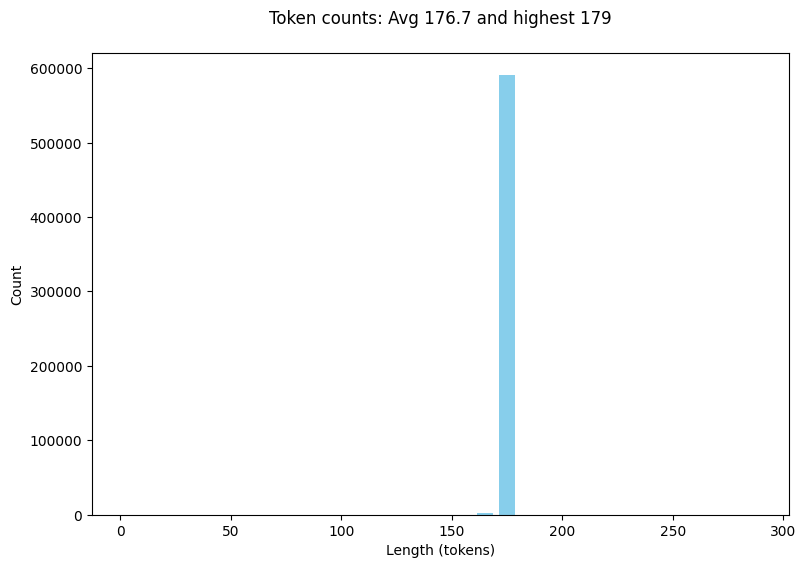

In [58]:
# Plot the distribution of token counts again

tokens = [item.token_count for item in items]
plt.figure(figsize=(9, 6))
plt.title(f"Token counts: Avg {sum(tokens)/len(tokens):,.1f} and highest {max(tokens):,}\n")
plt.xlabel('Length (tokens)')
plt.ylabel('Count')
plt.hist(tokens, rwidth=0.7, color="skyblue", bins=range(0, 300, 10))
plt.show()

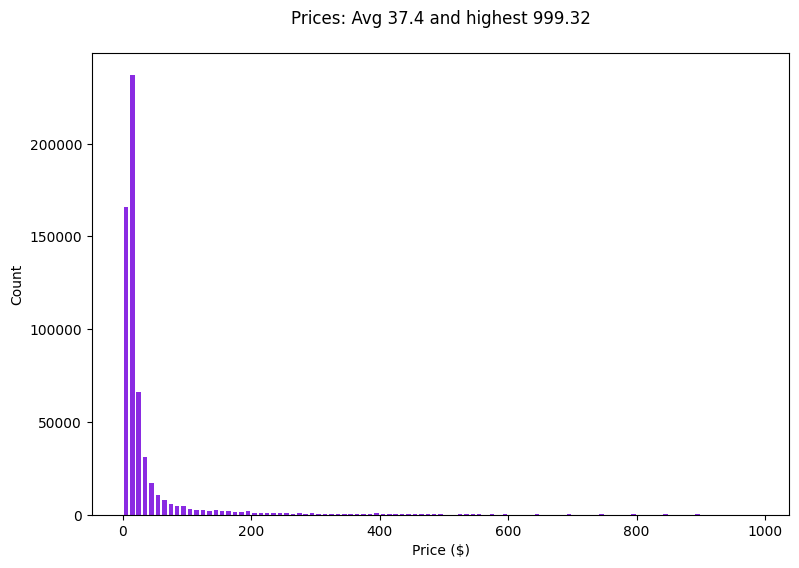

In [57]:
# Plot the distribution of prices

prices = [item.price for item in items]
plt.figure(figsize=(9, 6))
plt.title(f"Prices: Avg {sum(prices)/len(prices):,.1f} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="blueviolet", bins=range(0, 1000, 10))
plt.show()

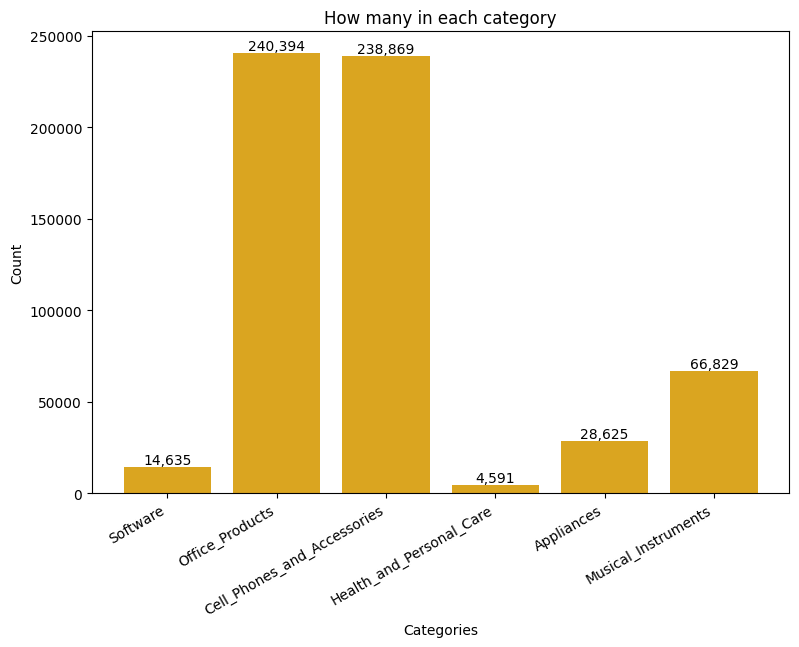

In [56]:
category_counts = Counter()
for item in items:
    category_counts[item.category]+=1

categories = category_counts.keys()
counts = [category_counts[category] for category in categories]

# Bar chart by category
plt.figure(figsize=(9, 6))
plt.bar(categories, counts, color="goldenrod")
plt.title('How many in each category')
plt.xlabel('Categories')
plt.ylabel('Count')

plt.xticks(rotation=30, ha='right')

# Add value labels on top of each bar
for i, v in enumerate(counts):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')

# Display the chart
plt.show()

# Objective

Craft a dataset which is more balanced in terms of prices. Less heavily scewed to cheap items, with an average that's higher than $60. Try to balance out the categories - fewer Automotive items.

In [28]:
# Create a dict with a key of each price from $1 to $999
# And in the value, put a list of items with that price (to nearest round number)

slots = defaultdict(list)
for item in items:
    slots[round(item.price)].append(item)

In [75]:
# Create a dataset called "sample" which tries to more evenly take from the range of prices
# And gives more weight to items from categories other than Automotive
# Set random seed for reproducibility

np.random.seed(42)
random.seed(42)
sample = []
for i in range(1, 1000):
    slot = slots[i]
    if i>=240:
        sample.extend(slot)
    elif len(slot) <= 1200:
        sample.extend(slot)
    else:

        category_weights = {
            'Musical_Instruments': 1.5,
            'Office_Products': 1.25,
            'Cell_Phones_and_Accessories': 3
        }
        
        weights = np.array([category_weights.get(item.category, 5) for item in slot])        
        # weights = np.array([1 if item.category in ('Musical_Instruments', 'Office_Products') else 6 for item in slot])
        weights = weights / np.sum(weights)
        selected_indices = np.random.choice(len(slot), size=1200, replace=False, p=weights)
        selected = [slot[i] for i in selected_indices]
        sample.extend(selected)

print(f"There are {len(sample):,} items in the sample")

There are 131,378 items in the sample


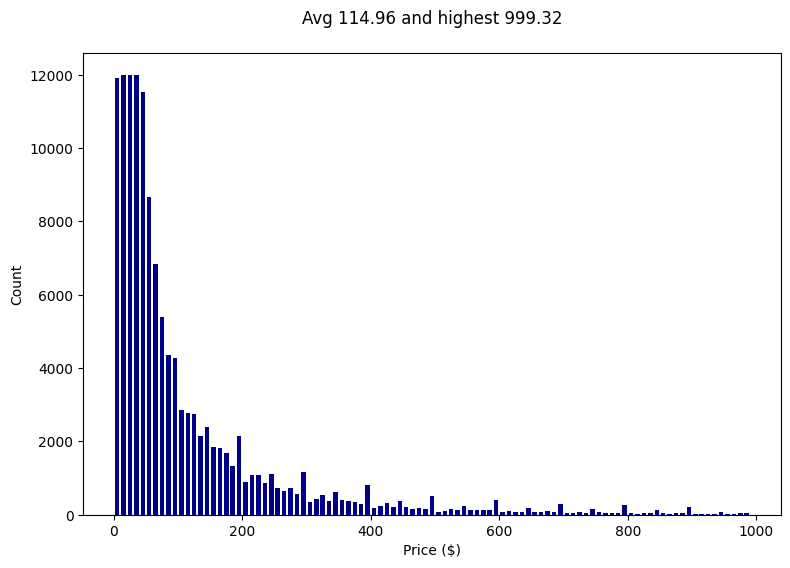

In [76]:
# Plot the distribution of prices in sample

prices = [float(item.price) for item in sample]
plt.figure(figsize=(9, 6))
plt.title(f"Avg {sum(prices)/len(prices):.2f} and highest {max(prices):,.2f}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="darkblue", bins=range(0, 1000, 10))
plt.show()

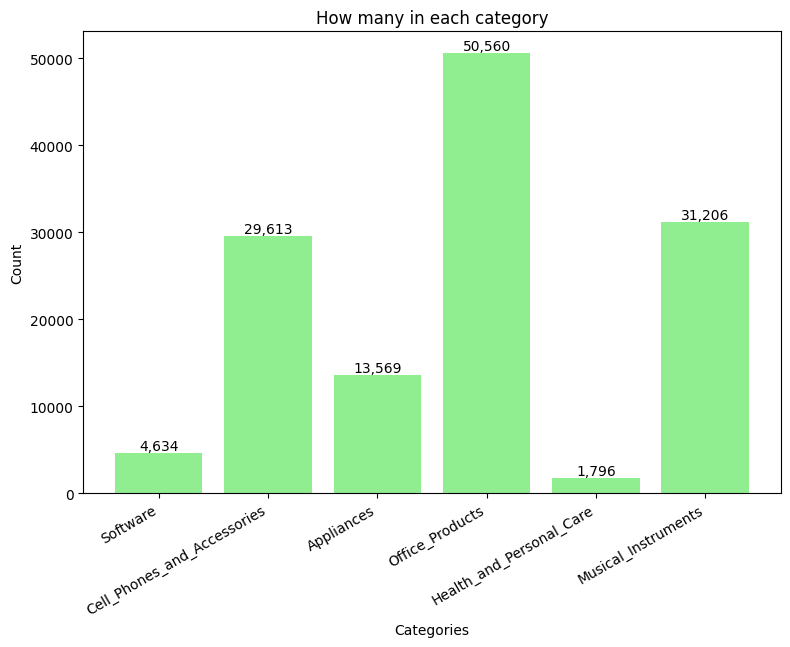

In [77]:
# OK, we did well in terms of raising the average price and having a smooth-ish population of prices
# Let's see the categories

category_counts = Counter()
for item in sample:
    category_counts[item.category]+=1

categories = category_counts.keys()
counts = [category_counts[category] for category in categories]

# Create bar chart
plt.figure(figsize=(9, 6))
plt.bar(categories, counts, color="lightgreen")

# Customize the chart
plt.title('How many in each category')
plt.xlabel('Categories')
plt.ylabel('Count')

plt.xticks(rotation=30, ha='right')

# Add value labels on top of each bar
for i, v in enumerate(counts):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')

# Display the chart
plt.show()

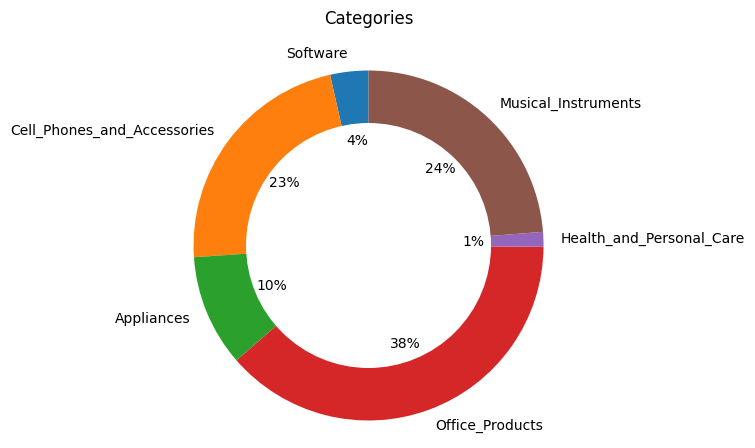

In [80]:
# Automotive still in the lead, but improved somewhat
# For another perspective, let's look at a pie

plt.figure(figsize=(7, 5))
plt.pie(counts, labels=categories, autopct='%1.0f%%', startangle=90)

# Add a circle at the center to create a donut chart (optional)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('Categories\n')

# Equal aspect ratio ensures that pie is drawn as a circle
plt.axis('equal')  

plt.show()

# Dataset Curated!

We've crafted an excellent dataset.

Let's do some final checks

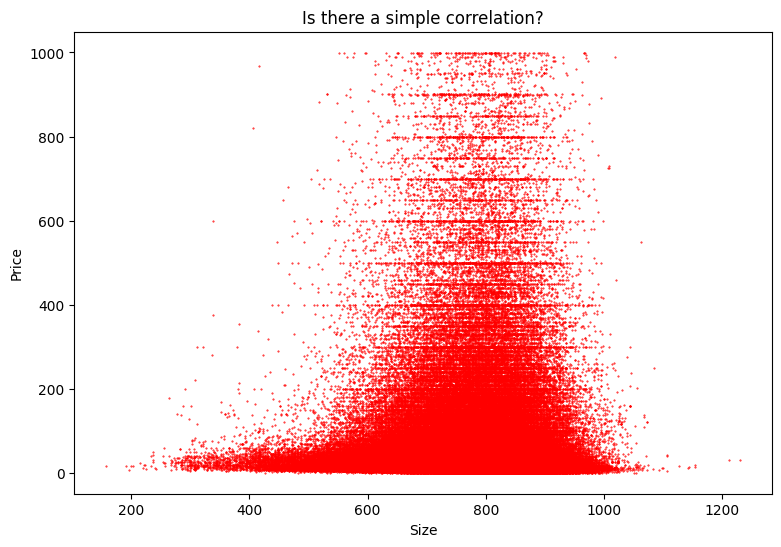

In [79]:
# How does the price vary with the character count of the prompt?

sample = items

sizes = [len(item.prompt) for item in sample]
prices = [item.price for item in sample]

# Create the scatter plot
plt.figure(figsize=(9, 6))
plt.scatter(sizes, prices, s=0.2, color="red")

# Add labels and title
plt.xlabel('Size')
plt.ylabel('Price')
plt.title('Is there a simple correlation?')

# Display the plot
plt.show()

In [72]:
def report(item):
    prompt = item.prompt
    tokens = Item.tokenizer.encode(item.prompt)
    print(f"Prompt: \n{prompt}")

    last_tokens = tokens[-10:]
    print(f"\nLast 10 tokens: {last_tokens}")
    print(f"Item tokenizer decode last 10 tokens: {Item.tokenizer.batch_decode(last_tokens)}")

In [74]:
report(sample[2000])

Prompt: 
How much does this cost to the nearest dollar?

CasesOnDeck Case Compatible with Motorola Moto E5 Play | Moto E5 Cruise Carbon Flex Moto E5 Play Rubberized Shock Shell Inner TPU Soft Interior (Fierce Tiger)
CasesonDeck Slim TACTICAL GRIP Case This Matte Flexible Single Layer case is compatible with the following models Motorola Moto E5 Play | Motorola Moto E5 Cruise *****ATTENTION BEFORE ORDERING***** Please double check you phone model is listed in the compatible models list above before ordering. THE CASE FlEX TACTICAL GRIP All-around protection is provided by our top class design and high quality craftsmanship.Multiple functions are available in one case, simplifying your life. Premium composition TPU Material and with unique designs bring a delicate and classic appearance. Stylish yet functional, perfect for your daily use. This is a

Price is $11.00

Last 10 tokens: [1115, 374, 264, 271, 7117, 374, 400, 806, 13, 410]
Item tokenizer decode last 10 tokens: [' This', ' is', 

In [86]:
report(sample[500000])

Prompt: 
How much does this cost to the nearest dollar?

PreSonus Eris E5 2-Way 5.25 Nearfield Studio Monitor Pair w/Stands & Cables
This specially priced monitor bundle for the PreSonus Eris E5 Active Nearfield Monitors - Pair - (High-Definition 2-way 5.25 ) also includes (2) 15 ft. TRS to XLR-Male balanced cables to connect the monitors to your recording interface or mixing console, and (2) Adjustable Monitor Stands to position and support the PreSonus Monitors. Specially Priced Package includes (2) PreSonus Eris E5 with all items as packaged by PreSonus, PLUS (2) 15 ft. TRS to XLR-Male balanced cables to connect to your interface or

Price is $350.00

Last 10 tokens: [701, 3834, 477, 271, 7117, 374, 400, 8652, 13, 410]
Item tokenizer decode last 10 tokens: [' your', ' interface', ' or', '\n\n', 'Price', ' is', ' $', '350', '.', '00']


## Observation

An interesting thing about the Llama tokenizer is that every number from 1 to 999 gets mapped to 1 token, much as we saw with gpt-4o. The same is not true of qwen2, gemma and phi3, which all map individual digits to tokens. This does turn out to be a bit useful for our project, although it's not an essential requirement.

# Finally

It's time to break down our data into a training, test and validation dataset.

It's typical to use 5%-10% of your data for testing purposes, but actually we have far more than we need at this point. We'll take 25,000 points for training, and we'll reserve 2,000 for testing, although we won't use all of them.


In [87]:
## Ramdon Sample => takes first 100_000 for training and next 3_000 for testing

random.seed(42)
random.shuffle(sample)
train = sample[:100_000]
test = sample[100_000:103_000]
print(f"Divided into a training set of {len(train):,} items and test set of {len(test):,} items")

Divided into a training set of 100,000 items and test set of 3,000 items


In [88]:
print(train[0].prompt)

How much does this cost to the nearest dollar?

Create A Monster
Create A Monster is a great fun App where you can build, design and make your own monstrously wacky creatures!Pick from a huge range monster parts, clothing, hair and accessories!When you are done, take a screenshot and send it to friends!If you make a mistake, or pick up a wrong part drop it into the trash! Great HD graphics Simple controls Huge range of items Unlimitless customisation Release Date 2012, Date first listed on Amazon June 21, 2012, Developed By Clockwork Shark Studios Ltd, Size 2.8MB, Version 1.0, Application Permissions Access information about networks, Access information about Wi-Fi networks, Open network sockets, Minimum Operating System Android 1.6, Approximate Download Time Less

Price is $1.00


In [89]:
print(test[0].test_prompt())

How much does this cost to the nearest dollar?

Holster for Sonim XP3 Plus Flip Phone, Nakedcellphone Black Rotating/Ratchet Belt Clip Holder Case with Secure Latch for T-Mobile/Verizon
LIKE A GLOVE Contoured Specifically for the Sonim Flip Phone; Keeps Your XP3900 Stable and Accessible at Close Range ROTATION Ratchet Clip Will Turn/Lock In Different Positions Vertical, Horizontal, etc. Low Profile Clip Keeps Your Phone Secure At Your Side. Industrial Durable Polycarbonate with Textured Matte Grid Pattern CARRY AND CONCEAL The Face-In Design Keeps Your Screen Protected and Concealed While on the Jobsite FREEDOM Free Your Pockets and Carry Your Phone in Comfort with Quick Access PLEASE READ This will NOT fit the standard XP3. Only fits the Correct model number is XP390

Price is $


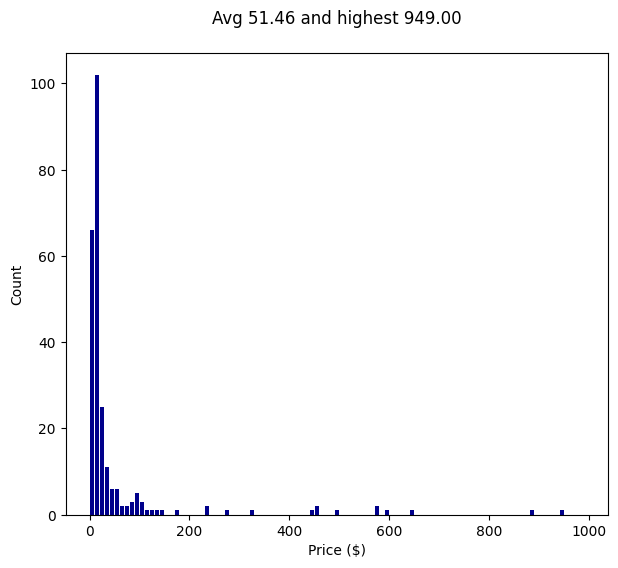

In [91]:
# Plot the distribution of prices in the first 250 test points

prices = [float(item.price) for item in test[:250]]
plt.figure(figsize=(7, 6))
plt.title(f"Avg {sum(prices)/len(prices):.2f} and highest {max(prices):,.2f}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="darkblue", bins=range(0, 1000, 10))
plt.show()

# Finally - upload your brand new dataset

Convert to prompts and upload to HuggingFace hub

In [92]:
train_prompts = [item.prompt for item in train]
train_prices = [item.price for item in train]
test_prompts = [item.test_prompt() for item in test]
test_prices = [item.price for item in test]

In [93]:
# Create a Dataset from the lists

train_dataset = Dataset.from_dict({"text": train_prompts, "price": train_prices})
test_dataset = Dataset.from_dict({"text": test_prompts, "price": test_prices})
dataset = DatasetDict({
    "train": train_dataset,
    "test": test_dataset
})

In [94]:
DATASET_NAME = "christseng898/lite-data"
dataset.push_to_hub(DATASET_NAME, private=True)

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/100 [00:00<?, ?ba/s]

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/3 [00:00<?, ?ba/s]

README.md:   0%|          | 0.00/412 [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/datasets/christseng898/lite-data/commit/293d2a2e4336785339df4cfb6e11c4092597613a', commit_message='Upload dataset', commit_description='', oid='293d2a2e4336785339df4cfb6e11c4092597613a', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/christseng898/lite-data', endpoint='https://huggingface.co', repo_type='dataset', repo_id='christseng898/lite-data'), pr_revision=None, pr_num=None)

In [95]:
# One more thing!
# Let's pickle the training and test dataset so we don't have to execute all this code next time!

with open('train_lite.pkl', 'wb') as file:
    pickle.dump(train, file)

with open('test_lite.pkl', 'wb') as file:
    pickle.dump(test, file)

## Todos for you:

- Investigate the dataset more!
- Confirm that the tokenizer tokenizes all 3 digit prices into 1 token

In [22]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

sample_prices = ["100", "249", "999"]
tokenized_prices = {price: tokenizer.tokenize(price) for price in sample_prices}
print(tokenized_prices)


{'100': ['100'], '249': ['249'], '999': ['999']}


### Investigate the dataset more!

In [23]:
from datasets import load_dataset, get_dataset_config_names
configs = get_dataset_config_names("McAuley-Lab/Amazon-Reviews-2023")
print(configs)

['raw_meta_All_Beauty', 'raw_meta_Toys_and_Games', 'raw_meta_Cell_Phones_and_Accessories', 'raw_meta_Industrial_and_Scientific', 'raw_meta_Gift_Cards', 'raw_meta_Musical_Instruments', 'raw_meta_Electronics', 'raw_meta_Handmade_Products', 'raw_meta_Arts_Crafts_and_Sewing', 'raw_meta_Baby_Products', 'raw_meta_Health_and_Household', 'raw_meta_Office_Products', 'raw_meta_Digital_Music', 'raw_meta_Grocery_and_Gourmet_Food', 'raw_meta_Sports_and_Outdoors', 'raw_meta_Home_and_Kitchen', 'raw_meta_Subscription_Boxes', 'raw_meta_Tools_and_Home_Improvement', 'raw_meta_Pet_Supplies', 'raw_meta_Video_Games', 'raw_meta_Kindle_Store', 'raw_meta_Clothing_Shoes_and_Jewelry', 'raw_meta_Patio_Lawn_and_Garden', 'raw_meta_Unknown', 'raw_meta_Books', 'raw_meta_Automotive', 'raw_meta_CDs_and_Vinyl', 'raw_meta_Beauty_and_Personal_Care', 'raw_meta_Amazon_Fashion', 'raw_meta_Magazine_Subscriptions', 'raw_meta_Software', 'raw_meta_Health_and_Personal_Care', 'raw_meta_Appliances', 'raw_meta_Movies_and_TV', 'raw_r

In [24]:
dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", name="5core_timestamp_w_his_Musical_Instruments", split="train")


In [25]:
print(dataset[0])
print(dataset.features)
print(f"Number of Musical Instruments: {len(dataset):,}")

{'user_id': 'AHV6QCNBJNSGLATP56JAWJ3C4G2A', 'parent_asin': 'B00OG187HC', 'rating': '5.0', 'timestamp': '1415286067000', 'history': ''}
{'user_id': Value(dtype='string', id=None), 'parent_asin': Value(dtype='string', id=None), 'rating': Value(dtype='string', id=None), 'timestamp': Value(dtype='string', id=None), 'history': Value(dtype='string', id=None)}
Number of Musical Instruments: 427,957


In [26]:
dataset1 = load_dataset("McAuley-Lab/Amazon-Reviews-2023", name="raw_meta_Handmade_Products", split="full", trust_remote_code=True)

In [27]:
print(dataset1[0])
print(dataset1.features)
print(f"Number of Handmade Product: {len(dataset1):,}")

{'main_category': 'Handmade', 'title': 'Daisy Keychain Wristlet Gray Fabric Key fob Lanyard', 'average_rating': 4.5, 'rating_number': 12, 'features': ['High Quality Fabrics', 'Antique Brass Metallic Hardware', '1" wide; Approx. 5-1/2" loop opening', 'Handmade in California'], 'description': ['This charming Daisy Fabric Keychain wristlet features an opening that loops around your wrist allowing your hands to be free to carry other things! This sweet floral daisy key fob will be your little dose of joy, lifting your spirits each time you reach for your keys! PRODUCT DETAILS: Approx. 7" long including the split ring to hold keys. Machine stitched over quality cotton fabric and firm interfacing on inside for structure yet comfortable to hold.'], 'price': 'None', 'images': {'hi_res': [None, None, 'https://m.media-amazon.com/images/I/51TpGYCdKIL._SL1000_.jpg', 'https://m.media-amazon.com/images/I/515dUKmwsbL._SL1000_.jpg', 'https://m.media-amazon.com/images/I/513oIHPmgUL._SL1000_.jpg'], 'lar